# Deepfake Image Detection



Kaggle Dataset

In [ ]:
KAGGLE_TOKEN = "KGAT_eab1bed27c165ff4808f1ee9f93f5e9a"

import os
os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
token_path = os.path.expanduser("~/.kaggle/access_token")
with open(token_path, "w") as f:
    f.write(KAGGLE_TOKEN)
os.chmod(token_path, 0o600)

print("Token saved.")


Token saved.


In [ ]:
!pip install -q kaggle
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces -p /content --unzip


Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [03:00<00:00, 22.3MB/s]



## Step 2: Data Loading

In [ ]:
import os, glob

candidates = glob.glob('/content/**/train/real', recursive=True)
assert len(candidates) > 0, "Dataset train/real folder not found"
DATA_ROOT = os.path.dirname(os.path.dirname(candidates[0]))
print("Dataset root found at:", DATA_ROOT)
print(os.listdir(DATA_ROOT))


Dataset root found at: /content/real_vs_fake/real-vs-fake
['valid', 'train', 'test']


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_dir = os.path.join(DATA_ROOT, "train")
valid_dir = os.path.join(DATA_ROOT, "valid")
test_dir  = os.path.join(DATA_ROOT, "test")

train_full = datasets.ImageFolder(train_dir, transform=train_transform)
valid_full = datasets.ImageFolder(valid_dir, transform=eval_transform)
test_full  = datasets.ImageFolder(test_dir,  transform=eval_transform)

print("Classes:", train_full.classes)
print("Sizes -> train:", len(train_full), "valid:", len(valid_full), "test:", len(test_full))


Using device: cuda
Classes: ['fake', 'real']
Sizes -> train: 100000 valid: 20000 test: 20000


In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(train_full, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(valid_full, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_full,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


## Step 3: Sample Images

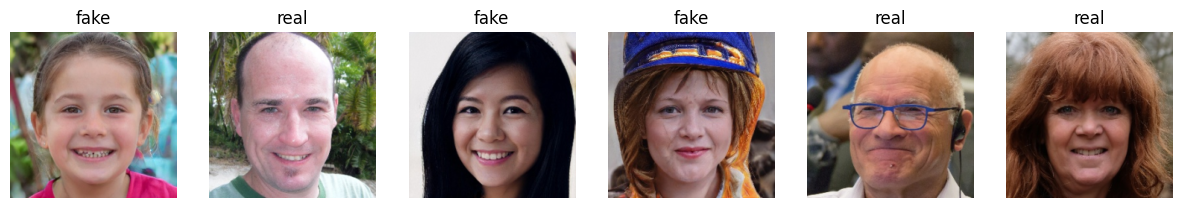

In [ ]:
def unnormalize(img_tensor):
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = img * np.array(STD) + np.array(MEAN)
    return np.clip(img, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    axes[i].imshow(unnormalize(images[i]))
    axes[i].set_title(train_full.classes[labels[i]])
    axes[i].axis("off")
plt.show()


## Step 4: Model (Transfer Learning with ResNet18)

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)
print(model.fc)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 94.8MB/s]


Linear(in_features=512, out_features=2, bias=True)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)


## Step 5: Training Loop

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total


### Stage 1 — Baseline Training (last layer only)

In [ ]:
EPOCHS = 5
best_val_acc = 0.0

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, valid_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Epoch {epoch+1}/{EPOCHS} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}  <- best so far, saved")
    else:
        print(f"Epoch {epoch+1}/{EPOCHS} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")

print("\nBaseline best validation accuracy:", best_val_acc)


Epoch 1/5 | train_acc=0.7766 | val_acc=0.7531  <- best so far, saved
Epoch 2/5 | train_acc=0.7961 | val_acc=0.8019  <- best so far, saved
Epoch 3/5 | train_acc=0.8017 | val_acc=0.8034  <- best so far, saved
Epoch 4/5 | train_acc=0.8033 | val_acc=0.8076  <- best so far, saved
Epoch 5/5 | train_acc=0.8020 | val_acc=0.7847

Baseline best validation accuracy: 0.80765


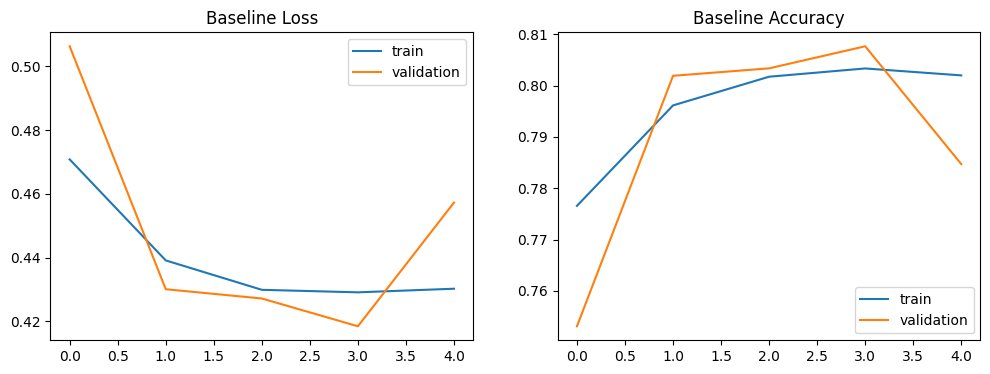

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="validation")
axes[0].set_title("Baseline Loss")
axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="validation")
axes[1].set_title("Baseline Accuracy")
axes[1].legend()
plt.show()


### Stage 2 — Full Fine-Tuning (entire network unfrozen)

In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam([
    {"params": model.layer1.parameters(), "lr": 1e-5},
    {"params": model.layer2.parameters(), "lr": 1e-5},
    {"params": model.layer3.parameters(), "lr": 5e-5},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
])

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", trainable)


Trainable parameters: 11177538


In [ ]:
EPOCHS = 6

history_finetune = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc = evaluate(model, valid_loader)

    history_finetune["train_loss"].append(train_loss)
    history_finetune["train_acc"].append(train_acc)
    history_finetune["val_loss"].append(val_loss)
    history_finetune["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Epoch {epoch+1}/{EPOCHS} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}  <- best so far, saved")
    else:
        print(f"Epoch {epoch+1}/{EPOCHS} | train_acc={train_acc:.4f} | val_acc={val_acc:.4f}")

model.load_state_dict(torch.load("best_model.pth"))
model.eval()
print("\nOverall best validation accuracy:", best_val_acc)


Epoch 1/6 | train_acc=0.9533 | val_acc=0.9851  <- best so far, saved
Epoch 2/6 | train_acc=0.9880 | val_acc=0.9875  <- best so far, saved
Epoch 3/6 | train_acc=0.9931 | val_acc=0.9926  <- best so far, saved
Epoch 4/6 | train_acc=0.9953 | val_acc=0.9930  <- best so far, saved
Epoch 5/6 | train_acc=0.9964 | val_acc=0.9935  <- best so far, saved
Epoch 6/6 | train_acc=0.9969 | val_acc=0.9965  <- best so far, saved

Overall best validation accuracy: 0.9965


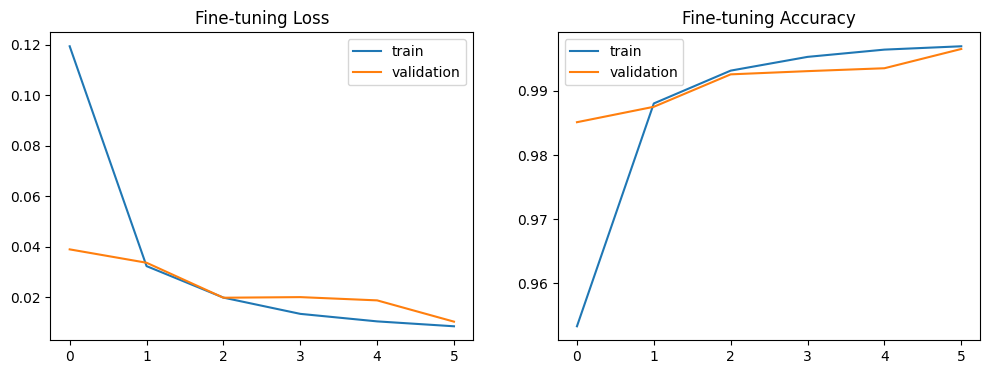

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_finetune["train_loss"], label="train")
axes[0].plot(history_finetune["val_loss"], label="validation")
axes[0].set_title("Fine-tuning Loss")
axes[0].legend()

axes[1].plot(history_finetune["train_acc"], label="train")
axes[1].plot(history_finetune["val_acc"], label="validation")
axes[1].set_title("Fine-tuning Accuracy")
axes[1].legend()
plt.show()


## Step 6: Evaluation (Precision, Recall, Confusion Matrix, ROC-AUC)

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay, classification_report
)

fake_idx = train_full.class_to_idx["fake"]
print("Fake class index:", fake_idx)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, fake_idx]
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {acc:.4f}\n")

print(classification_report(all_labels, all_preds, target_names=train_full.classes))


Fake class index: 0
Test Accuracy: 0.9958

              precision    recall  f1-score   support

        fake       1.00      1.00      1.00     10000
        real       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [ ]:
precision_fake = precision_score(all_labels, all_preds, pos_label=fake_idx)
recall_fake = recall_score(all_labels, all_preds, pos_label=fake_idx)
f1_fake = f1_score(all_labels, all_preds, pos_label=fake_idx)

print(f"Fake-class Precision: {precision_fake:.4f}")
print(f"Fake-class Recall:    {recall_fake:.4f}")
print(f"Fake-class F1:        {f1_fake:.4f}")


Fake-class Precision: 0.9953
Fake-class Recall:    0.9962
Fake-class F1:        0.9958


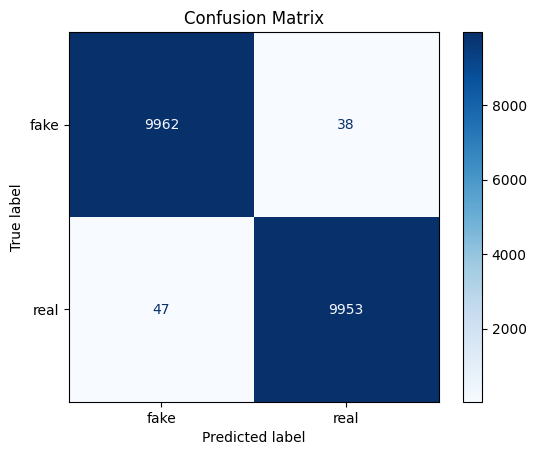

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_full.classes)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


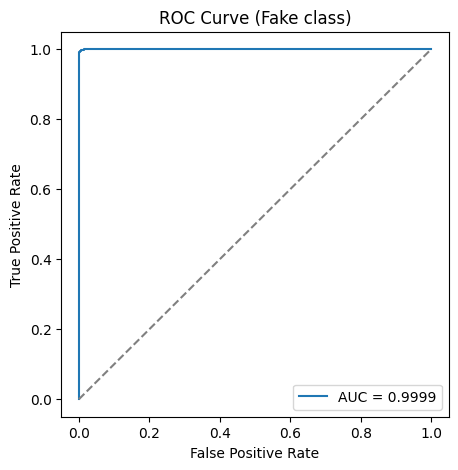

In [ ]:
fpr, tpr, _ = roc_curve(all_labels, all_probs, pos_label=fake_idx)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Fake class)")
plt.legend()
plt.show()


## Step 7: Save Model

In [ ]:
torch.save(model.state_dict(), "deepfake_resnet18.pth")
print("Model saved as deepfake_resnet18.pth")

from google.colab import files
files.download("deepfake_resnet18.pth")


Model saved as deepfake_resnet18.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Step 8: Inference on a New Image

In [ ]:
from PIL import Image

def predict_image(image_path, model, transform, class_names):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        confidence, pred_idx = torch.max(probs, 1)

    predicted_class = class_names[pred_idx.item()]
    confidence_pct = confidence.item() * 100

    print(f"Prediction: {predicted_class.upper()}")
    print(f"Confidence: {confidence_pct:.2f}%")

    plt.imshow(img)
    plt.title(f"{predicted_class.upper()} ({confidence_pct:.1f}%)")
    plt.axis("off")
    plt.show()

    return predicted_class, confidence_pct


Saving IMG 03 (fake).png to IMG 03 (fake).png
Prediction: FAKE
Confidence: 80.20%


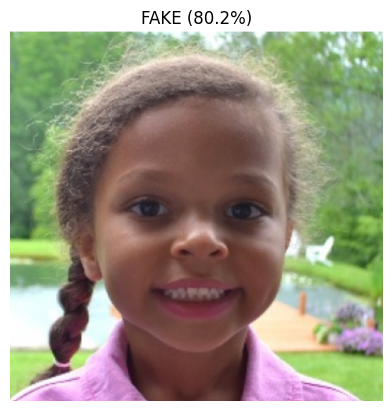

('fake', 80.19643425941467)

In [ ]:
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
predict_image(image_path, model, eval_transform, train_full.classes)
